In [2]:
import numpy as np
import pandas as pd

In [7]:
df = pd.read_csv('Telco_Customer_Churn.csv')
print("Shape of the dataset:", df.shape)
print("Dataset contains {} rows and {} columns.".format(df.shape[0], df.shape[1]))
print(df.info())
df.head()

Shape of the dataset: (7043, 21)
Dataset contains 7043 rows and 21 columns.
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 n

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [9]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print("Number of missing values in 'TotalCharges':", df['TotalCharges'].isnull().sum())
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)
df.info()

Number of missing values in 'TotalCharges': 11
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  Paperl

C:\Users\sanip\AppData\Local\Temp\ipykernel_17308\1493042390.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

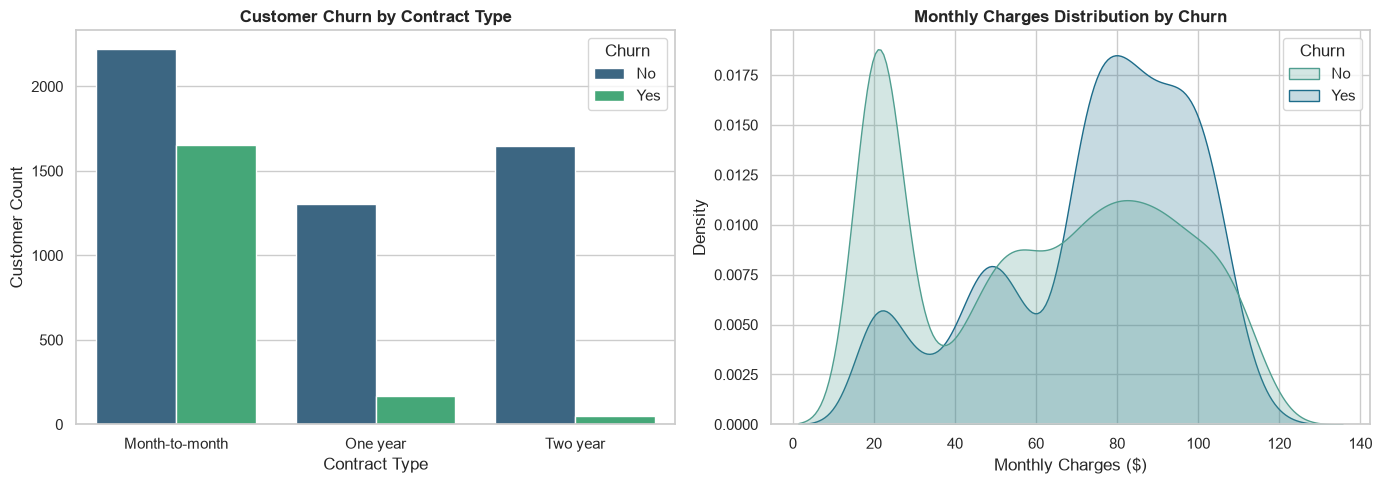

In [11]:
sns.set(style="whitegrid")
fig , axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Plot Churn Rate by Contract Type
sns.countplot(ax=axes[0], data=df, x='Contract', hue='Churn', palette='viridis')
axes[0].set_title('Customer Churn by Contract Type', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Contract Type')
axes[0].set_ylabel('Customer Count')

# 2. Distribution of Monthly Charges by Churn Status
sns.kdeplot(ax=axes[1], data=df, x='MonthlyCharges', hue='Churn', fill=True, common_norm=False, palette='crest')
axes[1].set_title('Monthly Charges Distribution by Churn', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Monthly Charges ($)')
axes[1].set_ylabel('Density')

plt.tight_layout()
plt.show()

In [12]:
# 3. Print Summary Statistics for Tenure and Charges by Churn Group
print("--- Summary Statistics by Churn Status ---")
print(df.groupby('Churn')[['tenure', 'MonthlyCharges', 'TotalCharges']].mean())

--- Summary Statistics by Churn Status ---
          tenure  MonthlyCharges  TotalCharges
Churn                                         
No     37.569965       61.265124   2555.344141
Yes    17.979133       74.441332   1531.796094


In [16]:
from sklearn.model_selection import train_test_split

df_model = df.drop(columns=['customerID'])

df_model['Churn'] = df_model['Churn'].map({'Yes': 1, 'No': 0})

df_encoded = pd.get_dummies(df_model, drop_first=True)

X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)
print("Training set churn distribution:\n", y_train.value_counts(normalize=True))
print("Testing set churn distribution:\n", y_test.value_counts(normalize=True))

Training set shape: (5634, 30)
Testing set shape: (1409, 30)
Training set churn distribution:
 Churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64
Testing set churn distribution:
 Churn
0    0.734564
1    0.265436
Name: proportion, dtype: float64


In [18]:
# Check if any NaNs exist in X_train or X_test
print("NaNs in X_train:", X_train.isnull().sum().sum())
print("NaNs in X_test: ", X_test.isnull().sum().sum())

# Fill any remaining NaNs with column medians
X_train = X_train.fillna(X_train.median())
X_test = X_test.fillna(X_train.median())

# Verify NaNs are now 0
print("\nAfter filling:")
print("NaNs in X_train:", X_train.isnull().sum().sum())
print("NaNs in X_test: ", X_test.isnull().sum().sum())

NaNs in X_train: 8
NaNs in X_test:  3

After filling:
NaNs in X_train: 0
NaNs in X_test:  0


=== Model Accuracy: 80.41% ===

=== Classification Report ===
              precision    recall  f1-score   support

Retained (0)       0.85      0.89      0.87      1035
 Churned (1)       0.65      0.56      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.74      1409
weighted avg       0.80      0.80      0.80      1409



c:\Users\sanip\anaconda3\envs\AIMLDS\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


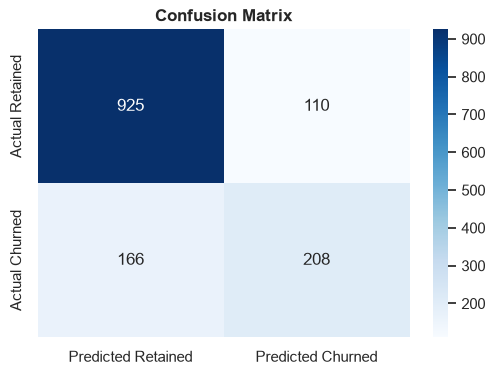

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Initialize Logistic Regression model
# max_iter=1000 ensures the optimization algorithm fully converges
model = LogisticRegression(max_iter=1000, random_state=42)

# 2. Train the model on the training data
model.fit(X_train, y_train)

# 3. Make predictions on the unseen test set
y_pred = model.predict(X_test)

# 4. Evaluate Accuracy and Metrics
accuracy = accuracy_score(y_test, y_pred)
print(f"=== Model Accuracy: {accuracy * 100:.2f}% ===\n")

print("=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=['Retained (0)', 'Churned (1)']))

# 5. Plot Confusion Matrix
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Retained', 'Predicted Churned'],
            yticklabels=['Actual Retained', 'Actual Churned'])
plt.title('Confusion Matrix', fontweight='bold')
plt.show()

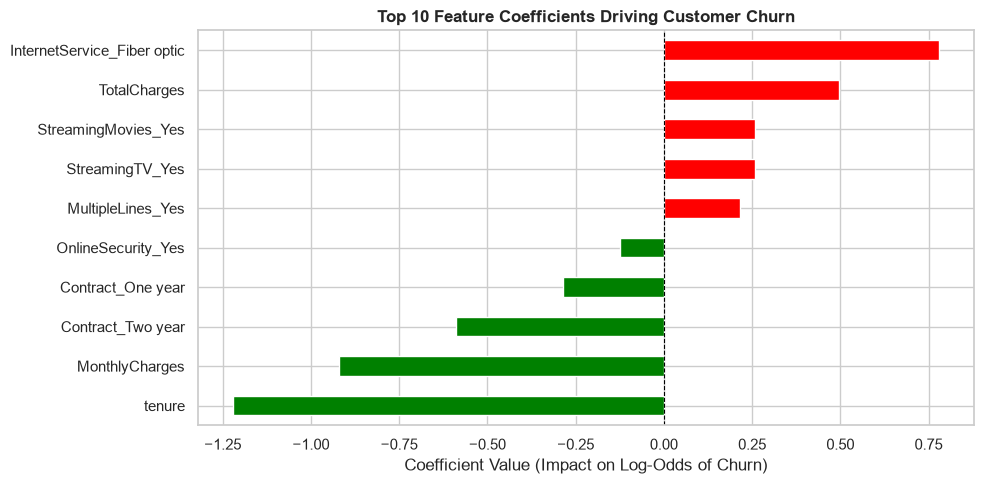


--- Key Insights from Model Coefficients ---
Top Factors INCREASING Churn Risk (Red):
InternetService_Fiber optic    0.778763
TotalCharges                   0.497255
StreamingMovies_Yes            0.258654
dtype: float64

Top Factors PROTECTING Retention (Green):
tenure              -1.219647
MonthlyCharges      -0.921379
Contract_Two year   -0.588978
dtype: float64


In [20]:
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Initialize StandardScaler
scaler = StandardScaler()

# 2. Fit and transform training features, transform test features
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame to keep column names
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

# 3. Retrain Logistic Regression on scaled data
model_scaled = LogisticRegression(max_iter=1000, random_state=42)
model_scaled.fit(X_train_scaled, y_train)

# 4. Extract Feature Coefficients (Top Churn Drivers)
coefficients = pd.Series(model_scaled.coef_[0], index=X_train.columns)

# Top 5 positive coefficients (Increase Churn Risk)
# Top 5 negative coefficients (Decrease Churn Risk / Protect Retention)
top_churn_drivers = pd.concat([coefficients.nlargest(5), coefficients.nsmallest(5)]).sort_values()

# 5. Plot Feature Importance Bar Chart
plt.figure(figsize=(10, 5))
colors = ['green' if x < 0 else 'red' for x in top_churn_drivers.values]
top_churn_drivers.plot(kind='barh', color=colors)
plt.title('Top 10 Feature Coefficients Driving Customer Churn', fontsize=12, fontweight='bold')
plt.xlabel('Coefficient Value (Impact on Log-Odds of Churn)')
plt.axvline(0, color='black', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.show()

print("\n--- Key Insights from Model Coefficients ---")
print("Top Factors INCREASING Churn Risk (Red):")
print(coefficients.nlargest(3))
print("\nTop Factors PROTECTING Retention (Green):")
print(coefficients.nsmallest(3))